In [1]:
import sys
sys.path.insert(0, '..')

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

from src.metrics.dominance import score_dominance_all, summarise_dominance

BASE     = Path('..') / 'results' / 'mas' / 'final_dataset'
W_VALUES = [1, 2, 5]
TOPOS    = ['fc', 'star']
DATASETS = ['gpqa', 'hiddenbench']

W_COLORS  = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}
DS_COLORS = {'gpqa': '#5470C6', 'hiddenbench': '#EE6666'}
T_COLORS  = {'fc': '#2c7bb6', 'star': '#d7191c'}
DS_LABELS = {'gpqa': 'GPQA', 'hiddenbench': 'HiddenBench'}
T_LABELS  = {'fc': 'Full-connected', 'star': 'Star'}

/Users/I550854/Documents/Master Thesis/self-organization-mas/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data & Run Dominance Analysis

For each (task, config) cell: run `score_dominance_all` on its 30 repetitions, then summarise.

In [2]:
cell_rows = []
rep_rows  = []

t0 = time.time()

for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    W    = d['W']
    ds   = d['dataset']
    topo = d.get('topology_name', 'fc')
    qid  = d['question_id']
    gt   = d['ground_truth']
    reps = d['repetitions']
    opts = list(d['options'].keys())
    M    = len(opts)
    N    = reps[0]['N']
    accuracy = float(np.mean([rep['correct'] for rep in reps]))

    rep_results = score_dominance_all(reps, B=1000, seed=42)
    summary     = summarise_dominance(rep_results)

    cell_rows.append({
        'dataset': ds, 'topology': topo, 'W': W, 'qid': qid,
        'ground_truth': gt, 'M': M, 'N': N, 'accuracy': accuracy,
        **summary,
    })

    for rep_idx, (rep, r) in enumerate(zip(reps, rep_results)):
        if r is None:
            continue
        majority = rep.get('majority_answer')
        rep_rows.append({
            'dataset': ds, 'topology': topo, 'W': W, 'qid': qid,
            'rep_idx': rep_idx,
            'D': r['D'],
            'z': r['z'],
            'p_value': r['p_value'],
            'flagged': r['flagged'],
            'hub': r['hub'],
            'hub_p': r['p'][r['hub']],
            'correct': rep.get('correct', None),
            'majority_correct': majority == gt if majority is not None else None,
        })

elapsed = time.time() - t0
df      = pd.DataFrame(cell_rows)
df_rep  = pd.DataFrame(rep_rows)

print(f'Done in {elapsed:.1f}s  |  cells: {len(df)}  |  rep records: {len(df_rep)}')
print(f'Excluded (no conversions): {df["n_excluded"].sum()} / {df["n_reps"].sum()}')

Done in 419.9s  |  cells: 420  |  rep records: 10888
Excluded (no conversions): 1712 / 12600


---
## Part 1 — D Distribution

Distribution of per-repetition $D$ across topologies and datasets.

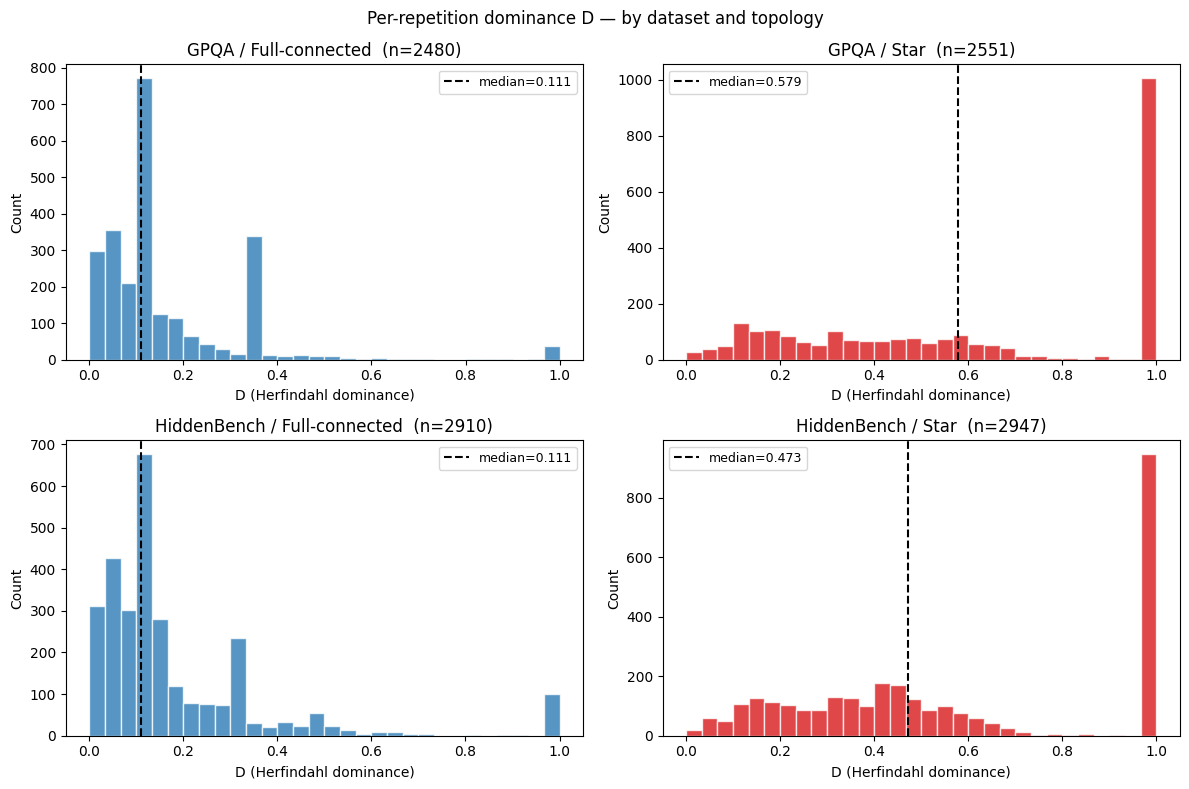

=== D summary ===
  GPQA         fc   : n= 2480  mean=0.159  median=0.111  std=0.158
  GPQA         star : n= 2551  mean=0.613  median=0.579  std=0.351
  HiddenBench  fc   : n= 2910  mean=0.185  median=0.111  std=0.201
  HiddenBench  star : n= 2947  mean=0.564  median=0.473  std=0.332


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row_idx, ds in enumerate(DATASETS):
    for col_idx, topo in enumerate(TOPOS):
        ax = axes[row_idx, col_idx]
        sub = df_rep[(df_rep['dataset']==ds) & (df_rep['topology']==topo)]
        ax.hist(sub['D'], bins=30, color=T_COLORS[topo], edgecolor='white', alpha=0.8)
        ax.axvline(sub['D'].median(), color='black', linestyle='--', lw=1.5,
                   label=f'median={sub["D"].median():.3f}')
        ax.set_xlabel('D (Herfindahl dominance)')
        ax.set_ylabel('Count')
        ax.set_title(f'{DS_LABELS[ds]} / {T_LABELS[topo]}  (n={len(sub)})')
        ax.legend(fontsize=9)

fig.suptitle('Per-repetition dominance D — by dataset and topology', fontsize=12)
plt.tight_layout()
plt.show()

print('=== D summary ===')  
for ds in DATASETS:
    for topo in TOPOS:
        sub = df_rep[(df_rep['dataset']==ds) & (df_rep['topology']==topo)]['D']
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: n={len(sub):5d}  mean={sub.mean():.3f}'
              f'  median={sub.median():.3f}  std={sub.std():.3f}')

---
## Part 2 — Detection Rate (Flagged Fraction)

Fraction of repetitions where the surrogate test flags excess concentration ($p < 0.05$).

=== Flagged fraction (p<0.05) — per (dataset, topology, W) ===
W                       1    2    5
dataset     topology               
gpqa        fc        0.0  0.0  0.0
            star      0.0  0.0  0.0
hiddenbench fc        0.0  0.0  0.0
            star      0.0  0.0  0.0



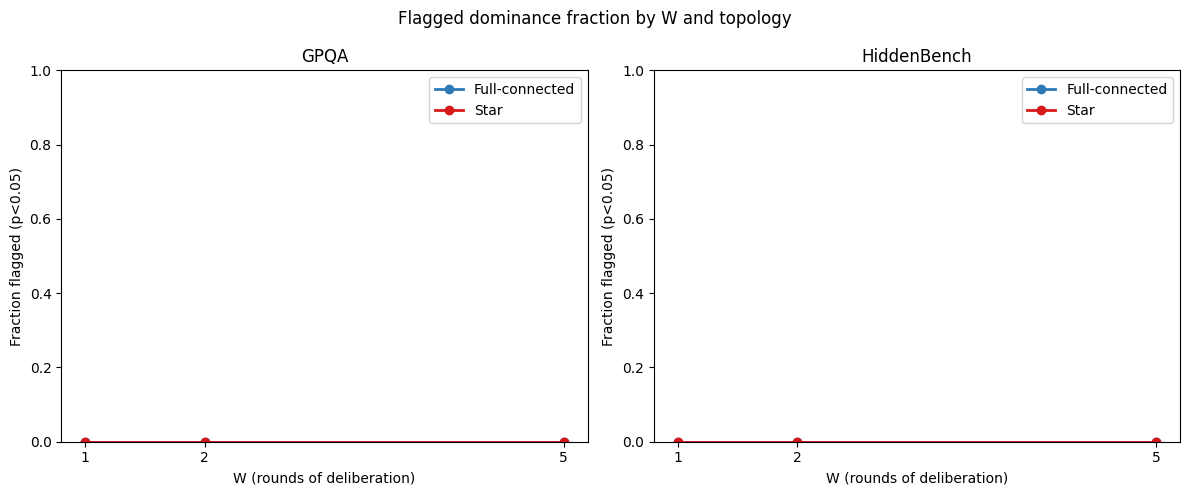

In [4]:
print('=== Flagged fraction (p<0.05) — per (dataset, topology, W) ===')
grp = df_rep.groupby(['dataset','topology','W'])['flagged'].mean().reset_index()
grp.columns = ['dataset','topology','W','flagged_fraction']
pivot = grp.pivot_table(index=['dataset','topology'], columns='W', values='flagged_fraction')
print(pivot.round(3).to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ds in zip(axes, DATASETS):
    sub = grp[grp['dataset']==ds]
    for topo in TOPOS:
        s = sub[sub['topology']==topo].sort_values('W')
        ax.plot(s['W'], s['flagged_fraction'], marker='o',
                color=T_COLORS[topo], label=T_LABELS[topo], linewidth=2)
    ax.set_xlabel('W (rounds of deliberation)')
    ax.set_ylabel('Fraction flagged (p<0.05)')
    ax.set_title(DS_LABELS[ds])
    ax.set_xticks(W_VALUES)
    ax.set_ylim(0, 1)
    ax.legend()

fig.suptitle('Flagged dominance fraction by W and topology', fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 3 — W Axis Effect

Directional signature: does $\bar{D}(W{=}5) > \bar{D}(W{=}2) > \bar{D}(W{=}1)$?

In [5]:
print('=== Mean D by (dataset, topology, W) ===')
grp_D = df_rep.groupby(['dataset','topology','W'])['D'].mean().reset_index()
pivot_D = grp_D.pivot_table(index=['dataset','topology'], columns='W', values='D')
print(pivot_D.round(4).to_string())
print()

print('=== Kruskal-Wallis: W effect on D (within dataset x topology) ===')
for ds in DATASETS:
    for topo in TOPOS:
        groups = [
            df_rep[(df_rep['dataset']==ds) & (df_rep['topology']==topo) & (df_rep['W']==w)]['D'].values
            for w in W_VALUES
        ]
        if any(len(g) < 2 for g in groups):
            continue
        stat, p = sp_stats.kruskal(*groups)
        means = [g.mean() for g in groups]
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: H={stat:.3f}  p={p:.4f}  '
              f'means={[round(m,3) for m in means]}')
print()

print('=== Pairwise MWU: W=1 vs W=5 ===')
for ds in DATASETS:
    for topo in TOPOS:
        g1 = df_rep[(df_rep['dataset']==ds) & (df_rep['topology']==topo) & (df_rep['W']==1)]['D']
        g5 = df_rep[(df_rep['dataset']==ds) & (df_rep['topology']==topo) & (df_rep['W']==5)]['D']
        if len(g1) < 2 or len(g5) < 2:
            continue
        stat, p = sp_stats.mannwhitneyu(g1, g5, alternative='two-sided')
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: W=1 mean={g1.mean():.3f}  W=5 mean={g5.mean():.3f}  p={p:.4f}')

=== Mean D by (dataset, topology, W) ===
W                          1       2       5
dataset     topology                        
gpqa        fc        0.1571  0.1628  0.1556
            star      0.5870  0.6326  0.6194
hiddenbench fc        0.1731  0.1925  0.1893
            star      0.5115  0.5904  0.5909

=== Kruskal-Wallis: W effect on D (within dataset x topology) ===
  GPQA         fc   : H=1.272  p=0.5295  means=[np.float64(0.157), np.float64(0.163), np.float64(0.156)]
  GPQA         star : H=8.847  p=0.0120  means=[np.float64(0.587), np.float64(0.633), np.float64(0.619)]
  HiddenBench  fc   : H=6.699  p=0.0351  means=[np.float64(0.173), np.float64(0.192), np.float64(0.189)]
  HiddenBench  star : H=48.209  p=0.0000  means=[np.float64(0.511), np.float64(0.59), np.float64(0.591)]

=== Pairwise MWU: W=1 vs W=5 ===
  GPQA         fc   : W=1 mean=0.157  W=5 mean=0.156  p=0.3533
  GPQA         star : W=1 mean=0.587  W=5 mean=0.619  p=0.0374
  HiddenBench  fc   : W=1 mean=0.173  W=5 

---
## Part 4 — Topology Comparison

Compare $z$-scores (excess over null) between fc and star to isolate behavioural concentration.

=== z-score (excess) by topology (per dataset, W) ===
GPQA
  W=1 fc   : mean_z=-0.227  (n=631)
  W=1 star : mean_z=-0.043  (n=368)
  W=2 fc   : mean_z=-0.208  (n=659)
  W=2 star : mean_z=-0.003  (n=361)
  W=5 fc   : mean_z=-0.229  (n=633)
  W=5 star : mean_z=-0.008  (n=387)

HiddenBench
  W=1 fc   : mean_z=-0.204  (n=696)
  W=1 star : mean_z=0.020  (n=500)
  W=2 fc   : mean_z=-0.139  (n=657)
  W=2 star : mean_z=0.031  (n=485)
  W=5 fc   : mean_z=-0.186  (n=661)
  W=5 star : mean_z=-0.025  (n=478)

=== MWU: z fc vs star ===
  GPQA         W=1: fc_z=-0.227  star_z=-0.043  p=0.0047
  GPQA         W=2: fc_z=-0.208  star_z=-0.003  p=0.0016
  GPQA         W=5: fc_z=-0.229  star_z=-0.008  p=0.0005
  HiddenBench  W=1: fc_z=-0.204  star_z=0.020  p=0.0001
  HiddenBench  W=2: fc_z=-0.139  star_z=0.031  p=0.0046
  HiddenBench  W=5: fc_z=-0.186  star_z=-0.025  p=0.0070


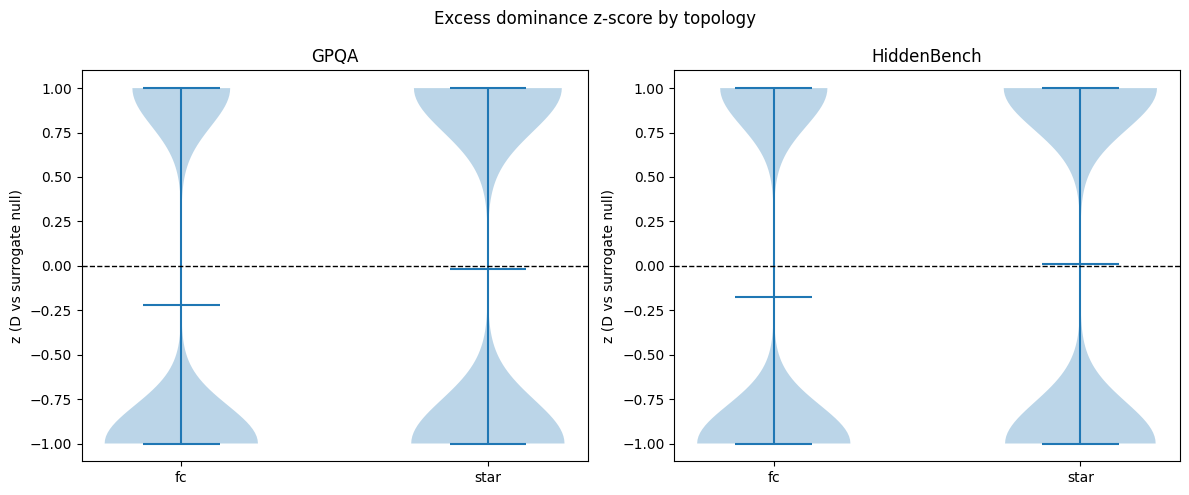

In [6]:
print('=== z-score (excess) by topology (per dataset, W) ===')
for ds in DATASETS:
    print(DS_LABELS[ds])
    for w in W_VALUES:
        for topo in TOPOS:
            sub = df_rep[(df_rep['dataset']==ds) & (df_rep['topology']==topo) & (df_rep['W']==w)]['z'].dropna()
            print(f'  W={w} {topo:5s}: mean_z={sub.mean():.3f}  (n={len(sub)})')
    print()

print('=== MWU: z fc vs star ===')
for ds in DATASETS:
    for w in W_VALUES:
        zfc   = df_rep[(df_rep['dataset']==ds) & (df_rep['topology']=='fc')   & (df_rep['W']==w)]['z'].dropna()
        zstar = df_rep[(df_rep['dataset']==ds) & (df_rep['topology']=='star') & (df_rep['W']==w)]['z'].dropna()
        if len(zfc) < 2 or len(zstar) < 2:
            continue
        stat, p = sp_stats.mannwhitneyu(zfc, zstar, alternative='two-sided')
        print(f'  {DS_LABELS[ds]:12s} W={w}: fc_z={zfc.mean():.3f}  star_z={zstar.mean():.3f}  p={p:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ds in zip(axes, DATASETS):
    data_fc   = df_rep[(df_rep['dataset']==ds) & (df_rep['topology']=='fc')]['z'].dropna()
    data_star = df_rep[(df_rep['dataset']==ds) & (df_rep['topology']=='star')]['z'].dropna()
    ax.violinplot([data_fc, data_star], positions=[1, 2], widths=0.5, showmeans=True)
    ax.axhline(0, color='black', linestyle='--', lw=1)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['fc', 'star'])
    ax.set_ylabel('z (D vs surrogate null)')
    ax.set_title(DS_LABELS[ds])

fig.suptitle('Excess dominance z-score by topology', fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 5 — Hub Concentration

Distribution of the hub agent's influence share $p_{\text{hub}}$. How often does the hub hold >50% of influence?

=== Hub influence share p_hub ===
  GPQA         fc   : mean=0.426  p(hub>=50%)=0.279  n=2480
  GPQA         star : mean=0.790  p(hub>=50%)=0.896  n=2551
  HiddenBench  fc   : mean=0.461  p(hub>=50%)=0.311  n=2910
  HiddenBench  star : mean=0.767  p(hub>=50%)=0.919  n=2947


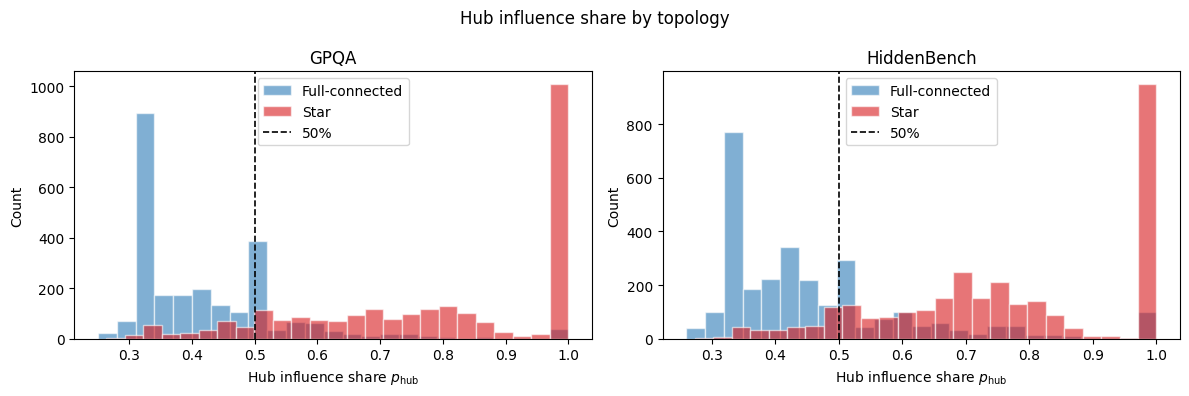

In [7]:
print('=== Hub influence share p_hub ===')
for ds in DATASETS:
    for topo in TOPOS:
        sub = df_rep[(df_rep['dataset']==ds) & (df_rep['topology']==topo)]['hub_p']
        frac_majority = (sub >= 0.5).mean()
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: mean={sub.mean():.3f}  '
              f'p(hub>=50%)={frac_majority:.3f}  n={len(sub)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, ds in zip(axes, DATASETS):
    for topo in TOPOS:
        sub = df_rep[(df_rep['dataset']==ds) & (df_rep['topology']==topo)]['hub_p']
        ax.hist(sub, bins=25, alpha=0.6, color=T_COLORS[topo], label=T_LABELS[topo], edgecolor='white')
    ax.axvline(0.5, color='black', linestyle='--', lw=1.2, label='50%')
    ax.set_xlabel('Hub influence share $p_{\\mathrm{hub}}$')
    ax.set_ylabel('Count')
    ax.set_title(DS_LABELS[ds])
    ax.legend()

fig.suptitle('Hub influence share by topology', fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 6 — Dominance vs Accuracy

Does higher dominance correlate with lower accuracy (entrenching the wrong leader)?

=== Spearman: D vs accuracy (cell-level) ===
  GPQA        : rho=-0.008  p=0.9045  n=210
  HiddenBench : rho=0.133  p=0.0548  n=210

=== Spearman: flagged_fraction vs accuracy (cell-level) ===
  GPQA        : rho=nan  p=nan  n=210
  HiddenBench : rho=nan  p=nan  n=210



/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_21268/3366556752.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = sp_stats.spearmanr(sub['flagged_fraction'], sub['accuracy'])
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_21268/3366556752.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = sp_stats.spearmanr(sub['flagged_fraction'], sub['accuracy'])


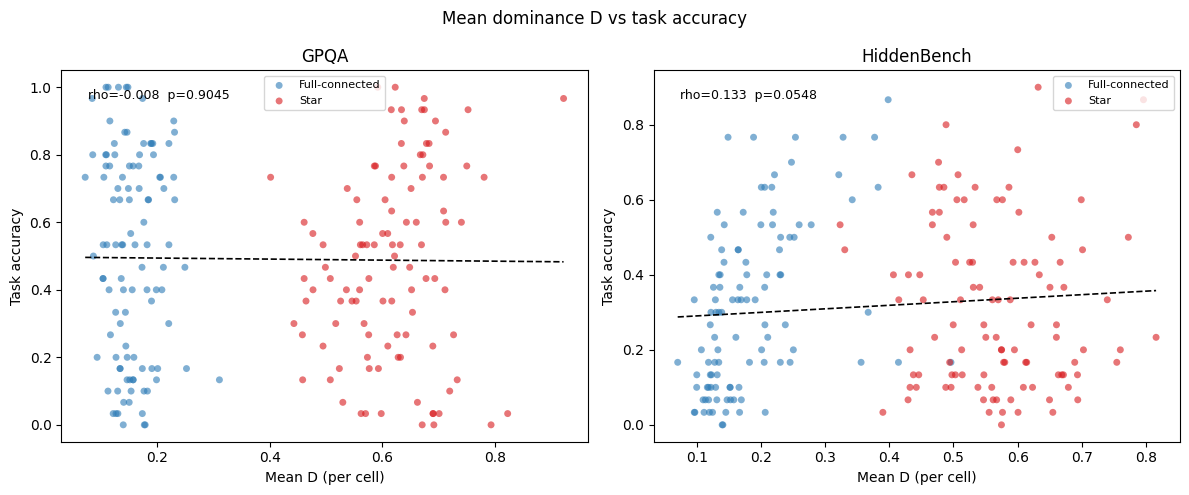

In [8]:
print('=== Spearman: D vs accuracy (cell-level) ===')
for ds in DATASETS:
    sub = df[df['dataset']==ds].dropna(subset=['D_mean','accuracy'])
    r, p = sp_stats.spearmanr(sub['D_mean'], sub['accuracy'])
    print(f'  {DS_LABELS[ds]:12s}: rho={r:.3f}  p={p:.4f}  n={len(sub)}')
print()

print('=== Spearman: flagged_fraction vs accuracy (cell-level) ===')
for ds in DATASETS:
    sub = df[df['dataset']==ds].dropna(subset=['flagged_fraction','accuracy'])
    r, p = sp_stats.spearmanr(sub['flagged_fraction'], sub['accuracy'])
    print(f'  {DS_LABELS[ds]:12s}: rho={r:.3f}  p={p:.4f}  n={len(sub)}')
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ds in zip(axes, DATASETS):
    sub = df[df['dataset']==ds].dropna(subset=['D_mean','accuracy'])
    for topo in TOPOS:
        s = sub[sub['topology']==topo]
        ax.scatter(s['D_mean'], s['accuracy'], color=T_COLORS[topo],
                   s=25, alpha=0.6, label=T_LABELS[topo], edgecolors='none')
    rho, p = sp_stats.spearmanr(sub['D_mean'], sub['accuracy'])
    m, b = np.polyfit(sub['D_mean'], sub['accuracy'], 1)
    xs = np.linspace(sub['D_mean'].min(), sub['D_mean'].max(), 50)
    ax.plot(xs, m*xs+b, color='black', linestyle='--', lw=1.2)
    ax.text(0.05, 0.95, f'rho={rho:.3f}  p={p:.4f}',
            transform=ax.transAxes, fontsize=9, va='top')
    ax.set_xlabel('Mean D (per cell)')
    ax.set_ylabel('Task accuracy')
    ax.set_title(DS_LABELS[ds])
    ax.legend(fontsize=8)

fig.suptitle('Mean dominance D vs task accuracy', fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 7 — Dominance vs Persuasiveness Cross-Check

Dominance is the concentration of $Pers$ influence; high mean persuasiveness $\neq$ high dominance.

In [9]:
from src.metrics.persuasiveness import Persuasiveness

pers_metric = Persuasiveness()
pers_cell_rows = []

for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    W    = d['W']
    ds   = d['dataset']
    topo = d.get('topology_name', 'fc')
    qid  = d['question_id']
    reps = d['repetitions']

    scores = pers_metric.score_all(reps)
    flat   = [s for rep_s in scores for s in rep_s if s is not None]
    mean_p = float(np.mean(flat)) if flat else float('nan')
    std_p  = float(np.std(flat))  if len(flat) > 1 else float('nan')

    # inequality (std) of per-agent scores within rep
    ineq = []
    for rep_s in scores:
        valid_s = [s for s in rep_s if s is not None]
        if len(valid_s) > 1:
            ineq.append(float(np.std(valid_s)))
    mean_ineq = float(np.mean(ineq)) if ineq else float('nan')

    pers_cell_rows.append({'dataset': ds, 'topology': topo, 'W': W, 'qid': qid,
                           'mean_pers': mean_p, 'std_pers': std_p, 'mean_ineq_pers': mean_ineq})

df_pers = pd.DataFrame(pers_cell_rows)
df_merged = df.merge(df_pers, on=['dataset','topology','W','qid'])

print('=== Spearman: D_mean vs persuasiveness inequality (std across agents) ===')
for ds in DATASETS:
    sub = df_merged[df_merged['dataset']==ds].dropna(subset=['D_mean','mean_ineq_pers'])
    r, p = sp_stats.spearmanr(sub['D_mean'], sub['mean_ineq_pers'])
    print(f'  {DS_LABELS[ds]:12s}: rho={r:.3f}  p={p:.4f}  n={len(sub)}')
print()

print('=== Spearman: D_mean vs mean Pers ===')
for ds in DATASETS:
    sub = df_merged[df_merged['dataset']==ds].dropna(subset=['D_mean','mean_pers'])
    r, p = sp_stats.spearmanr(sub['D_mean'], sub['mean_pers'])
    print(f'  {DS_LABELS[ds]:12s}: rho={r:.3f}  p={p:.4f}  n={len(sub)}')

=== Spearman: D_mean vs persuasiveness inequality (std across agents) ===
  GPQA        : rho=-0.175  p=0.0110  n=210
  HiddenBench : rho=-0.225  p=0.0010  n=210

=== Spearman: D_mean vs mean Pers ===
  GPQA        : rho=-0.174  p=0.0115  n=210
  HiddenBench : rho=-0.105  p=0.1284  n=210


---
## Summary

---
## Part 8 — Why Does W Matter Only in Star?

The W-effect on D is significant in star but flat in fc. This cell unpacks the mechanism:
- Does the **hub's influence share** grow with W (not just D)?
- Does **conversion volume** increase with W, and does that amplify hub concentration?
- Is the hub identity **stable** (same agent keeps winning across repetitions at W=5 vs W=1)?


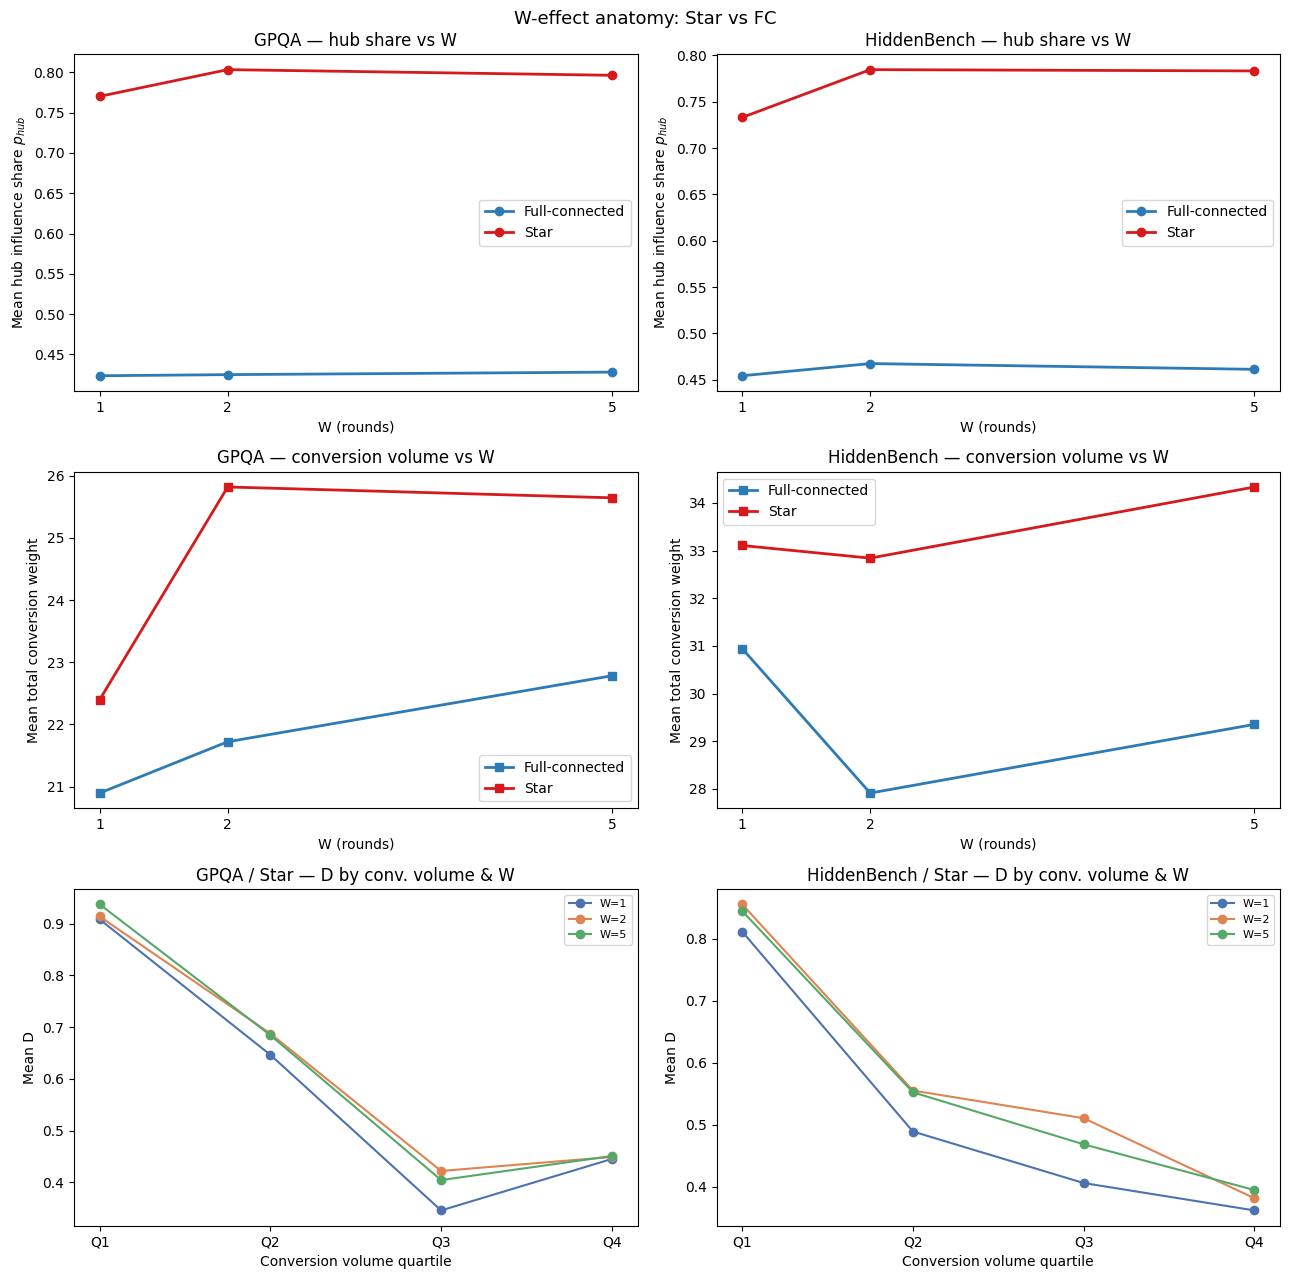

=== Hub share by (topology, W) — pooled across datasets ===
topology  W  mean   std
      fc  1 0.440 0.143
      fc  2 0.448 0.149
      fc  5 0.446 0.149
    star  1 0.750 0.214
    star  2 0.793 0.192
    star  5 0.789 0.196

=== Conversion volume by (topology, W) — pooled ===
topology  W   mean    std
      fc  1 25.920 24.173
      fc  2 24.816 23.643
      fc  5 26.068 26.791
    star  1 27.752 24.134
    star  2 29.330 33.945
    star  5 29.990 33.908


=== Interpretation ===

Hypothesis: in STAR, more rounds (higher W) give the centre more opportunities
to be the sole eligible source for a conversion — each round is another chance
for a leaf to flip to the centre's vote when only the centre already holds it.
This structurally amplifies concentration.

In FC every agent has equal access, so extra rounds add conversions distributed
across all agents — no single agent accumulates disproportionate credit.

Row 2 (conversion volume) shows whether W actually increases total conversio

In [11]:
from src.metrics.dominance import _influence_graph

fig, axes = plt.subplots(3, 2, figsize=(13, 13))
fig.suptitle('W-effect anatomy: Star vs FC', fontsize=13)

# ── 1. Hub influence share p_hub by W ────────────────────────────────────────
for col_ax, ds in zip([axes[0,0], axes[0,1]], DATASETS):
    grp = (df_rep[df_rep['dataset']==ds]
           .groupby(['topology','W'])['hub_p'].mean().reset_index())
    for topo in TOPOS:
        s = grp[grp['topology']==topo].sort_values('W')
        col_ax.plot(s['W'], s['hub_p'], marker='o', color=T_COLORS[topo],
                    label=T_LABELS[topo], linewidth=2)
    col_ax.set_xlabel('W (rounds)')
    col_ax.set_ylabel('Mean hub influence share $p_{hub}$')
    col_ax.set_title(f'{DS_LABELS[ds]} — hub share vs W')
    col_ax.set_xticks(W_VALUES)
    col_ax.legend()

# ── 2. Conversion volume by W (total edge weight per repetition) ──────────────
conv_rows = []
for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    W    = d['W']
    ds   = d['dataset']
    topo = d.get('topology_name', 'fc')
    qid  = d['question_id']
    for ri, rep in enumerate(d['repetitions']):
        G = _influence_graph(rep)          # N×N weight matrix
        total_conv = float(G.sum())
        conv_rows.append({'dataset': ds, 'topology': topo, 'W': W, 'qid': qid,
                          'rep_idx': ri, 'total_conv': total_conv})

df_conv = pd.DataFrame(conv_rows)

for col_ax, ds in zip([axes[1,0], axes[1,1]], DATASETS):
    for topo in TOPOS:
        grp = (df_conv[(df_conv['dataset']==ds) & (df_conv['topology']==topo)]
               .groupby('W')['total_conv'].mean().reset_index())
        col_ax.plot(grp['W'], grp['total_conv'], marker='s', color=T_COLORS[topo],
                    label=T_LABELS[topo], linewidth=2)
    col_ax.set_xlabel('W (rounds)')
    col_ax.set_ylabel('Mean total conversion weight')
    col_ax.set_title(f'{DS_LABELS[ds]} — conversion volume vs W')
    col_ax.set_xticks(W_VALUES)
    col_ax.legend()

# ── 3. D by conversion-volume quartile, coloured by W ────────────────────────
conv_lookup = {(r.dataset, r.topology, r.W, r.qid, r.rep_idx): r.total_conv
               for r in df_conv.itertuples()}

df_rep_aug = df_rep.copy().reset_index(drop=True)
df_rep_aug['total_conv'] = [
    conv_lookup.get((r.dataset, r.topology, r.W, r.qid, r.rep_idx), 0.0)
    for r in df_rep_aug.itertuples()
]

for col_ax, (ds, topo) in zip([axes[2,0], axes[2,1]],
                               [('gpqa','star'), ('hiddenbench','star')]):
    sub = df_rep_aug[(df_rep_aug['dataset']==ds) & (df_rep_aug['topology']==topo)]
    sub = sub[sub['total_conv'] > 0].copy()
    sub['conv_bin'] = pd.qcut(sub['total_conv'], q=4, labels=['Q1','Q2','Q3','Q4'])
    for w, c in W_COLORS.items():
        s = sub[sub['W']==w].groupby('conv_bin', observed=True)['D'].mean().reset_index()
        col_ax.plot(s['conv_bin'].astype(str), s['D'], marker='o',
                    color=c, label=f'W={w}', linewidth=1.5)
    col_ax.set_xlabel('Conversion volume quartile')
    col_ax.set_ylabel('Mean D')
    col_ax.set_title(f'{DS_LABELS[ds]} / Star — D by conv. volume & W')
    col_ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Numeric summary ────────────────────────────────────────────────────────────
print('=== Hub share by (topology, W) — pooled across datasets ===')
g = df_rep.groupby(['topology','W'])['hub_p'].agg(['mean','std']).reset_index()
print(g.round(3).to_string(index=False))
print()

print('=== Conversion volume by (topology, W) — pooled ===')
g2 = df_conv.groupby(['topology','W'])['total_conv'].agg(['mean','std']).reset_index()
print(g2.round(3).to_string(index=False))
print()

print("""
=== Interpretation ===

Hypothesis: in STAR, more rounds (higher W) give the centre more opportunities
to be the sole eligible source for a conversion — each round is another chance
for a leaf to flip to the centre's vote when only the centre already holds it.
This structurally amplifies concentration.

In FC every agent has equal access, so extra rounds add conversions distributed
across all agents — no single agent accumulates disproportionate credit.

Row 2 (conversion volume) shows whether W actually increases total conversions.
Row 3 shows whether D still grows with W *within the same conversion-volume
quartile* — if yes, the effect is not just more volume but concentration of
that volume onto fewer sources, confirming the structural amplification story.
""")


In [12]:
print('=== DOMINANCE ANALYSIS — SUMMARY ===')
print()
print(f'Total repetitions  : {df["n_reps"].sum():,}')
print(f'Valid (conversions) : {df["n_valid"].sum():,}')
print(f'Excluded (no conv.) : {df["n_excluded"].sum():,}')
print()

print(f'Mean D across all   : {df_rep["D"].mean():.3f}')
print(f'Median D across all : {df_rep["D"].median():.3f}')
print(f'Flagged fraction    : {df_rep["flagged"].mean():.3f}')
print()

print('Per dataset:')
for ds in DATASETS:
    sub = df_rep[df_rep['dataset']==ds]
    print(f'  {DS_LABELS[ds]:12s}: D_mean={sub["D"].mean():.3f}  '
          f'flagged={sub["flagged"].mean():.3f}  n={len(sub)}')
print()

print('Per topology:')
for topo in TOPOS:
    sub = df_rep[df_rep['topology']==topo]
    print(f'  {topo:5s}: D_mean={sub["D"].mean():.3f}  '
          f'z_mean={sub["z"].dropna().mean():.3f}  '
          f'flagged={sub["flagged"].mean():.3f}  n={len(sub)}')

=== DOMINANCE ANALYSIS — SUMMARY ===

Total repetitions  : 12,600
Valid (conversions) : 10,888
Excluded (no conv.) : 1,712

Mean D across all   : 0.382
Median D across all : 0.258
Flagged fraction    : 0.000

Per dataset:
  GPQA        : D_mean=0.389  flagged=0.000  n=5031
  HiddenBench : D_mean=0.376  flagged=0.000  n=5857

Per topology:
  fc   : D_mean=0.173  z_mean=-0.198  flagged=0.000  n=5390
  star : D_mean=0.587  z_mean=-0.003  flagged=0.000  n=5498
